# PyTorch Lightning fine-tuning template

by Andrés Muñoz-Jaramillo

This notebook is meant to act as a template to train and use a surya model to implement DS application.

It focuses on the concept of defining a modified Surya model, loading its weigths, and using a PyTorch lightning training loop to train it

This notebook assumes familiarity with the concepts of datasets and dataloaders contained in the **_0_dataset_dataloader_template.ipynb_**

It doesn't require having seen the baselines template, but they are meant to complement each other.  **_In fact they are on purpose almost identical!!!_**

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.   

In [1]:
%cd /data001/finetuning_dh/surya_workshop/downstream_apps/Imagetranslation

/data001/finetuning_dh/surya_workshop/downstream_apps/Imagetranslation


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import sys
print(sys.executable)


/data001/finetuning_dh/conda_envs/surya_dhegde/bin/python


In [4]:
import os, subprocess, sys
print(
    subprocess.check_output(
        ["strings", "-a", "/data001/finetuning_dh/conda_envs/surya_dhegde/lib/libstdc++.so.6"]
    ).decode().splitlines()[-5:]
)


['.debug_line', '.debug_str', '.debug_line_str', '.debug_loclists', '.debug_rnglists']


In [5]:
import torch
print(torch.cuda.is_available(), torch.cuda.device_count())
import os, torch, socket
print("host:", socket.gethostname())
print("cuda:", torch.cuda.is_available(), "count:", torch.cuda.device_count())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))


True 1
host: gpu001
cuda: True count: 1
CUDA_VISIBLE_DEVICES: 0


Here we initalize variables related to Weights and Biases, our online logging system to ensure they are user specific

In [ ]:
# Make sure wandb logs are stored in a user-specific directory
# Set writable directories
#os.environ["WANDB_DIR"] = "./wandb/wandb_logs"
#os.environ["WANDB_CACHE_DIR"] = "./wandb/wandb_cache"
#os.environ["WANDB_CONFIG_DIR"] = "./wandb/wandb_config"
# Optional:
#os.environ["TMPDIR"] = "./wandb/wandb_tmp"

# Ensure directories exist (optional, wandb usually creates them)
#os.makedirs(os.environ["WANDB_DIR"], exist_ok=True)
#os.makedirs(os.environ["WANDB_CACHE_DIR"], exist_ok=True)
#os.makedirs(os.environ["WANDB_CONFIG_DIR"], exist_ok=True)
#os.makedirs(os.environ["TMPDIR"], exist_ok=True)

In [6]:

import sys
from torch.utils.data import DataLoader

import torch
import yaml

# import lightning as L
# from lightning.pytorch.callbacks import ModelCheckpoint
# from lightning.pytorch.loggers import CSVLogger, WandbLogger

import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, WandbLogger

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.
sys.path.append("../../Surya")

from surya.utils.data import build_scalers  # Data scaling utilities for Surya stacks
from workshop_infrastructure.utils import apply_peft_lora
torch.set_float32_matmul_precision('medium')



## Download scalers and Weights
Surya input data needs to be scaled properly for the model to work and this cell downloads the scaling information.  In this notebook we also download the model weights for finetuning


- If the cell below fails, try running the provided shell script directly in the terminal.
- Sometimes the download may fail due to network or server issues—if that happens, simply re-run the script a few times until it completes successfully.

In [7]:
!sh download_scalers_and_weights.sh

==> Checking assets directory at: /data001/finetuning_dh/surya_workshop/downstream_apps/Imagetranslation/assets
==> Downloading scalers and model weights into: /data001/finetuning_dh/surya_workshop/downstream_apps/Imagetranslation/assets
Traceback (most recent call last):
  File "<stdin>", line 2, in <module>
ModuleNotFoundError: No module named 'huggingface_hub'


## Load configuration

Surya was designed to read a configuration file that defines many aspects of the model
including the data it uses we use this config file to set default values that do not
need to be modified, but also to define values specific to our downstream application

In [8]:
# Configuration paths - modify these if your files are in different locations
config_path = "./configs/config.yaml"

# Load configuration
print("📋 Loading configuration...")
try:
    config = yaml.safe_load(open(config_path, "r"))
    config["data"]["scalers"] = yaml.safe_load(open(config["data"]["scalers_path"], "r"))
    print("✅ Configuration loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Make sure config.yaml exists in your current directory")
    raise
dtype_map = {
    "float16": torch.float16,
    "bfloat16": torch.bfloat16,
    "float32": torch.float32,
}
config["dtype"] = dtype_map[config["dtype"]]

scalers = build_scalers(info=config["data"]["scalers"])

print("Configured dtype:", config["dtype"])

📋 Loading configuration...
✅ Configuration loaded successfully!
Configured dtype: torch.bfloat16


## Define Downstream (DS) datasets

This child class takes as input all expected HelioFM parameters, plus additonal parameters relevant to the downstream application.  Here we focus in particular to the DS index and parameters necessary to combine it with the HelioFM index.

Another important component of creating a dataset class for your DS is normalization.  Here we use a log normalization on xray flux that will act as the output target.  Making log10(xray_flux) strictly positive and having 66% of its values between 0 and 1

In this case we will define both a training and a validation dataset using the indices pointed at in the config

**_Important:  In this notebook we sets max_number_of_samples=6 to potentially avoid going through the whole dataset as we explore it.  Keep in mind this for the future in case the database seems smaller than you expect_**


In [9]:
from downstream_apps.Imagetranslation.datasets.EUV2MAG_Dataset import EUV2MAGDataset

In [10]:
%mkdir -p /tmp/helio_s3_cache

In [11]:
import os
os.makedirs("/tmp/helio_s3_cache", exist_ok=True)

In [ ]:
# The Training dataset
train_dataset = EUV2MAGDataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=config["data"]["train_data_path"],
    time_delta_input_minutes=config["data"]["time_delta_input_minutes"],
    time_delta_target_minutes=config["data"]["time_delta_target_minutes"],
    n_input_timestamps=config["model"]["time_embedding"]["time_dim"],
    rollout_steps=config["rollout_steps"],
    channels=config["data"]["channels"],
    drop_hmi_probability=config["drop_hmi_probablity"],
    use_latitude_in_learned_flow=config["use_latitude_in_learned_flow"],
    scalers=scalers,
    phase="train",
    s3_use_simplecache=False,
    s3_cache_dir="/tmp/helio_s3_cache",
    s3_storage_options={"anon": True},
    #### Put your donwnstream (DS) specific parameters below this line
    input_channels=["aia304", "aia193", "aia171"],
    target_channels=["hmi_m"],
    return_surya_stack=True,
    max_number_of_samples=100,
    sampling_seed=42
)

# Create the Validation dataset
val_dataset = EUV2MAGDataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=config["data"]["valid_data_path"],  #<---------------- different index path
    time_delta_input_minutes=config["data"]["time_delta_input_minutes"],
    time_delta_target_minutes=config["data"]["time_delta_target_minutes"],
    n_input_timestamps=config["model"]["time_embedding"]["time_dim"],
    rollout_steps=config["rollout_steps"],
    channels=config["data"]["channels"],
    drop_hmi_probability=config["drop_hmi_probablity"],
    use_latitude_in_learned_flow=config["use_latitude_in_learned_flow"],
    scalers=scalers,
    phase="validation",
    s3_use_simplecache = False,
    s3_cache_dir= "/tmp/helio_s3_cache",  
    s3_storage_options={"anon": True},  
    #### Put your donwnstream (DS) specific parameters below this line
    input_channels=["aia304", "aia193", "aia171"],
    target_channels=["hmi_m"],
    return_surya_stack=True,
    max_number_of_samples=20,
    sampling_seed=42
)


We also intialize separate training and validation dataloaders.   Since we are working in a shared environment.  Using multiprocessing_context="spawn" helps avoid lockups.

In [13]:
batch_size = 1

train_data_loader = DataLoader(
                dataset=train_dataset,
                batch_size=batch_size,
                shuffle=True,
                num_workers=4,
                multiprocessing_context="spawn",
                persistent_workers=True,
                pin_memory=True,
            )

val_data_loader = DataLoader(
                dataset=val_dataset,
                batch_size=batch_size,
                num_workers=4,
                multiprocessing_context="spawn",
                persistent_workers=True,
                pin_memory=True,
            )

## Initialize the HelioSpectformer model

This is the main difference beteween the notebook that trains the simple model and the one that fine-tunes Surya.  

In the case of the finetuning exercise one of the main differences between DS applications is the dimensionality of the output.  In this notebook we use a modified HelioSpectformer that projects into a 1D space. 

**_IMPORTANT: If your DS application is 2D you need to use the HelioSpectformer2D_**

In [14]:
from workshop_infrastructure.models.finetune_models import HelioSpectformer2D

/data001/finetuning_dh/conda_envs/surya_dhegde/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [23]:
import torch.nn as nn

input_channels = ["aia304", "aia193", "aia171"]
target_channels = ["hmi_m"]

class ChannelAdapter(nn.Module):
    def __init__(self, model, num_data_chans, out_chans):
        super().__init__()
        self.adapter = nn.Conv3d(num_data_chans, out_chans, kernel_size=1, padding=0)
        self.model = model

    def forward(self, batch):
        batch["ts"] = self.adapter(batch["ts"])
        return self.model(batch)

# Keep output channels in sync with your target channels
config["model"]["ft_out_chans"] = len(target_channels)


In [24]:
model = HelioSpectformer2D(
    img_size=config["model"]["img_size"],
    patch_size=config["model"]["patch_size"],
    in_chans=config["model"]["in_channels"],  # keep pretrained channel count (13)
    embed_dim=config["model"]["embed_dim"],
    time_embedding=config["model"]["time_embedding"],
    depth=config["model"]["depth"],
    num_heads=config["model"]["num_heads"],
    mlp_ratio=config["model"]["mlp_ratio"],
    drop_rate=config["model"]["drop_rate"],
    dtype=config["dtype"],
    window_size=config["model"]["window_size"],
    dp_rank=config["model"]["dp_rank"],
    learned_flow=config["model"]["learned_flow"],
    use_latitude_in_learned_flow=config["use_latitude_in_learned_flow"],
    init_weights=config["model"]["init_weights"],
    checkpoint_layers=config["model"]["checkpoint_layers"],
    n_spectral_blocks=config["model"]["spectral_blocks"],
    rpe=config["model"]["rpe"],
    finetune=config["model"]["finetune"],
    config=config,
)

model = ChannelAdapter(
    model,
    num_data_chans=len(input_channels),      # 3
    out_chans=config["model"]["in_channels"] # 13
)


Now the config file really comes into bear. The Spectformer has a metric ton of hyperparameters

## Load model weights

Here we load the pre-trained checkpoint and load the weights.  The exercise of loading follows the idea of us as many of the weights as possible.  This is accomplished through the filtered_checkpoint_state.   It checks to see if the pretrained model's layers match those of your finetuning architecture.   It also checks that all your dimensions across layers check out.   If something does not work those paramameters are left in their random initialization. 

In [ ]:
# model_state = model.state_dict()
# checkpoint_state = torch.load(config["pretrained_path"], weights_only=True, map_location="cpu")
# filtered_checkpoint_state = {
#     k: v
#     for k, v in checkpoint_state.items()
#     if k in model_state and v.shape == model_state[k].shape
# }

# # 2. Load the filtered weights
# model_state.update(filtered_checkpoint_state)
# model.load_state_dict(model_state, strict=True)

In [ ]:
# model_state = model.state_dict()
# checkpoint_state = torch.load(
#     config["pretrained_path"], weights_only=True, map_location="cpu"
# )

# matched = {}
# for key, value in checkpoint_state.items():
#     if not key.startswith(("embedding.", "backbone.")):
#         continue  # Do not load the pretraining decoder.

#     model_key = "model." + key
#     if model_key in model_state and value.shape == model_state[model_key].shape:
#         matched[model_key] = value

# print("Loaded pretrained tensors:", len(matched), "/", len(checkpoint_state))
# print("Example matches:", list(matched)[:8])
# assert matched, "No pretrained weights loaded"

# model_state.update(matched)
# model.load_state_dict(model_state, strict=True)

Loaded pretrained tensors: 156 / 159
Example matches: ['model.embedding.pos_embed', 'model.embedding.patch_embed.proj.bias', 'model.backbone.blocks_spectral_gating.0.norm1.weight', 'model.backbone.blocks_spectral_gating.0.norm1.bias', 'model.backbone.blocks_spectral_gating.0.filter.complex_weight', 'model.backbone.blocks_spectral_gating.0.norm2.weight', 'model.backbone.blocks_spectral_gating.0.norm2.bias', 'model.backbone.blocks_spectral_gating.0.mlp.fc1.weight']


<All keys matched successfully>

In [25]:
model_state = model.state_dict()
checkpoint_state = torch.load(
    config["pretrained_path"], weights_only=True, map_location="cpu"
)
matched = {}

for key, value in checkpoint_state.items():
    if not key.startswith(("embedding.", "backbone.")):
        continue  # Do not load the pretraining output decoder.

    model_key = "model." + key
    if model_key not in model_state:
        continue

    if key == "embedding.patch_embed.proj.weight":
        # Checkpoint: [1280, 13 × 2, 16, 16]
        # One-frame model: [1280, 13, 16, 16]
        assert value.shape[1] == 26
        adapted = value.reshape(
            value.shape[0], 13, 2, *value.shape[2:]
        ).sum(dim=2)

        assert adapted.shape == model_state[model_key].shape
        matched[model_key] = adapted

    elif value.shape == model_state[model_key].shape:
        matched[model_key] = value

print(f"Loaded pretrained tensors: {len(matched)} / {len(checkpoint_state)}")
print("Adapted projection:", matched["model.embedding.patch_embed.proj.weight"].shape)
assert len(matched) == 157

model_state.update(matched)
model.load_state_dict(model_state, strict=True)

Loaded pretrained tensors: 157 / 159
Adapted projection: torch.Size([1280, 13, 16, 16])


<All keys matched successfully>

In [26]:
key = "embedding.patch_embed.proj.weight"
print("Checkpoint:", checkpoint_state[key].shape)
print("Your model:", model_state["model." + key].shape)
print("Was loaded:", "model." + key in matched)

Checkpoint: torch.Size([1280, 26, 16, 16])
Your model: torch.Size([1280, 13, 16, 16])
Was loaded: True


## To LoRA or not to Lora

This cell gives you two options.  On the one hand we have the classic freezing of the backbone (the initial layers of the model).   On the other hand we have the use of a LoRA.

LoRas have been a remarkable addition to our arsenal of models.   They have the advantage of keeping pretty much the entire model intact and only add broad modifications to weights as needed.

In [27]:
use_LoRa = True

if use_LoRa:
    model = apply_peft_lora(model, config)
else:
    for name, param in model.named_parameters():
        if "embedding" in name or "backbone" in name:
            param.requires_grad = False
    parameters_with_grads = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            parameters_with_grads.append(name)
    print(
        f"{len(parameters_with_grads)} parameters require gradients: {', '.join(parameters_with_grads)}."
    )

Applying PEFT LoRA with configuration: {'r': 8, 'lora_alpha': 64, 'target_modules': ['q_proj', 'v_proj', 'k_proj', 'out_proj', 'fc1', 'fc2'], 'lora_dropout': 0.1, 'bias': 'none'}
trainable params: 1,024,000 || all params: 359,019,060 || trainable%: 0.29%


In [28]:
for name, parameter in model.named_parameters():
    if ".adapter." in name or ".unembed." in name:
        parameter.requires_grad_(True)

trainable = [n for n, p in model.named_parameters() if p.requires_grad]

print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Adapter:", [n for n in trainable if ".adapter." in n])
print("Decoder:", [n for n in trainable if ".unembed." in n])
print("LoRA tensors:", sum("lora_" in n for n in trainable))

assert any(".adapter." in n for n in trainable)
assert any(".unembed." in n for n in trainable)
assert any("lora_" in n for n in trainable)

Trainable parameters: 1351988
Adapter: ['base_model.model.adapter.weight', 'base_model.model.adapter.bias']
Decoder: ['base_model.model.model.unembed.unembed.0.weight', 'base_model.model.model.unembed.unembed.0.bias']
LoRA tensors: 40


We can now test that this model manipulates a batch as expected and returns an estimate of flare intensity as we did for the simple baseline.

We pass the input stack 'ts' to the model to transform it into our regression output.   Note that since this model was trained for a different task, it's likely it won't perform very well.  As with the simple baseline, this only acts as a test that our model forward doesn't have dimension problems.

Dimension problemns are the dominant source of error in this kind of work.

Note that our output has now the size of our batch.

In [29]:
batch = next(iter(train_data_loader))
output = model.forward(batch)  # Get rid of singleton dimension
output

tensor([[[[ 0.5765,  0.9020, -0.1276,  ..., -0.7614, -0.0107,  0.1825],
          [-1.0967, -0.0582,  0.0929,  ..., -0.7160, -0.2893,  0.9376],
          [ 0.0283,  0.0079,  0.2561,  ..., -0.5817,  0.8805,  0.2979],
          ...,
          [ 0.6857,  0.2405,  0.6904,  ..., -0.4112, -0.1471, -0.1057],
          [-0.0242,  0.0027,  0.4855,  ..., -1.3344,  0.1110, -0.2098],
          [ 0.8878,  0.3409,  0.2990,  ..., -0.9952, -1.5109, -0.2636]]]],
       grad_fn=<PixelShuffleBackward0>)

## Define your metrics

Metrics are a very important part of training AI models.   They provide your models with the quantitification of error, which in turn shifts the weights towards better pefrorming models.  They also provide a way for you to monitor performance, identify overfitting, and quantify value added. 

We now initialize the metrics class which allows you to control what metrics do you want to use as "loss" (i.e. the metrics that backpropagate through your model) and which ones for monitoring performance.  As with other components, this takes the form of a loaded module that can be later use in a training script

In [30]:
from downstream_apps.Imagetranslation.metrics.template_metrics import ImageTranslationMetrics

In [31]:
train_loss_metrics = ImageTranslationMetrics("train_loss")
train_evaluation_metrics = ImageTranslationMetrics("train_metrics")
validation_evaluation_metrics = ImageTranslationMetrics("val_metrics")

Now they can be evaluated in our model's output and our ground truth.   First the loss that actually will backpropagate, in this case Mean Squared Errror

%train_loss_metrics(output, batch["forecast"])

In [32]:
target = batch["forecast"].squeeze(2)  # remove forecast-time dimension

print("Prediction:", output.shape)
print("Target:", target.shape)
assert output.shape == target.shape

train_loss_metrics(output, target)

Prediction: torch.Size([1, 1, 4096, 4096])
Target: torch.Size([1, 1, 4096, 4096])


({'mse': tensor(1.6233, grad_fn=<MseLossBackward0>)}, [1])

Then a training evaluation that will not backpropagate and inform our model, but that we can keep an eye on. Note that reporting lots of metrics during training will slow the training process.  I'm including it her as an example, but oftentimes is better to put the diagnostics only in the validation evaluation metrics.

Here we are caclulating the Root Relative Squared Error https://lightning.ai/docs/torchmetrics/stable/regression/rse.html 

A value below one means the prediction is better than predicting the average.  It is unlikely that this metric will be lower than one with a randomly initialized model

In [33]:
target = batch["forecast"].squeeze(2)
train_evaluation_metrics(output, target)

({'mse': tensor(1.6233), 'mae': tensor(0.7553)}, [1, 1])

In the validation evaluation metrics we report both MSE and RRSE

In [34]:
validation_evaluation_metrics(output, target)

({'mse': tensor(1.6233), 'mae': tensor(0.7553)}, [1, 1])

## Define your PyTorch ligthning module

In this workshop we will use PyTorch lightning to train our models.  PyTorch lighting reduces the amount of code required to implement a training loop in comparison to PyTorch (at the expense of control and versatility).  

Opening the FlareLightningModule shows a simple Lightning model implementation.  It consists of:

- An initialization of the class (metrics, model, and learning rate).
- The forward code that runs evaluation of the model.
- Training and validation steps.
- Configuration of optimizers.

**_Note that it is the same Lightning module we used for the baseline!!_**

In [35]:
from downstream_apps.Imagetranslation.lightning_modules.pl_simple_baseline import ImageTranslationLightningModule

## Set your global seeds

Since training AI models generally uses stochastic gradient descent, it is a good idea to fix your random seeds so that your training exercise is reproducible.    

In [36]:
L.seed_everything(42, workers=True)

[rank: 0] Seed set to 42


42

## Intialize Lightning module

Now we properly initalize the Lightning module to enable training, including passing the dictionary of metrics

In [37]:
metrics = {'train_loss': train_loss_metrics,
           'train_metrics': train_evaluation_metrics,
           'val_metrics': validation_evaluation_metrics}

learning_rate = 1e-3
lit_model = ImageTranslationLightningModule(model, metrics, lr=learning_rate, batch_size=batch_size)

## Logging

In order to properly compare experiments against each other, it is very useful to log evaluation metrics in a place where they can be compared against other training runs.  In this workshop we will use Weights and Biases (WandB). 

The first time you run WandB in a machine it will ask you to login to WandB.  You should have received an invitation to our project.  In order to login you must:

- Select option 2 (existing account).   In VScode the dialog opens a box at the top of your screen.
- Click on get API Key (this will open a browser).
- Generate API Key.
- Paste it in the dialog box at the top of your VSCode

In [ ]:
project_name = "Imagetranslation_surya"
run_name = "Finetuning_100train_20val_pilot_v1"

wandb_logger = WandbLogger(
    entity="dinesha-hegde-the-university-of-alabama-in-huntsville",
    project=project_name,
    name=run_name,
    log_model=False,
    save_dir="./wandb/wandb_tmp",
)

csv_logger = CSVLogger("runs", name="Imagetranslation_surya")

In [ ]:
import sys, socket, torch

print("Python:", sys.executable)
print("Host:", socket.gethostname())
print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

## Initialize trainer

With the loggers done, now the trainer needs to be defined.  The trainer defines several properties of your training run. Here we define:

- The max number of epochs (one epoch represents your model seeing your entire training dataset).
- Define where the training run will take place (auto uses the GPU if possible, if not, CPU).
- The loggers.
- The callbacks (here we save the model with the lowest validation loss).
- Logging frequency (because we are working with a small dataset it needs to be small).


**Note that in this notebook we also set a mixed precision to reduce the model's footprint in memory.**

In [39]:
max_epochs = 1

# -------------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------------
trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    precision="bf16-mixed", 
    logger=[wandb_logger, csv_logger],
    callbacks=[
        ModelCheckpoint(
            monitor="val_loss",
            mode="min",
            save_top_k=1,
        )
    ],
    log_every_n_steps=2,
)

/data001/finetuning_dh/conda_envs/surya_dhegde/lib/python3.12/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data001/finetuning_dh/conda_envs/surya_dhegde/lib/p ...
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

Finally we fit the model.  We pass the Lighting module, and our dataloaders.

In [40]:
trainer.fit(lit_model, train_data_loader, val_data_loader)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/dhegde/.netrc.
wandb: Currently logged in as: dinesha-hegde (dinesha-hegde-the-university-of-alabama-in-huntsville) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/data001/finetuning_dh/conda_envs/surya_dhegde/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type      | Params | Mode  | FLOPs
----------------------------------------------------
0 | model | PeftModel | 359 M  | train | 0    
----------------------------------------------------
1.4 M     Trainable params
357 M     Non-trainable params
359 M     Total params
1,436.076 Total estimated model params size (MB)
372       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=1` reached.


In [41]:
print("Checkpoint tensors:", len(checkpoint_state))
print("Matched tensors:", len(matched))

Checkpoint tensors: 159
Matched tensors: 157


In [42]:
print("Checkpoint keys:", list(checkpoint_state)[:8])
print("Model keys:", list(model_state)[:12])

Checkpoint keys: ['embedding.pos_embed', 'embedding.patch_embed.proj.weight', 'embedding.patch_embed.proj.bias', 'unembed.unembed.0.weight', 'unembed.unembed.0.bias', 'backbone.blocks_spectral_gating.0.norm1.weight', 'backbone.blocks_spectral_gating.0.norm1.bias', 'backbone.blocks_spectral_gating.0.filter.complex_weight']
Model keys: ['adapter.weight', 'adapter.bias', 'model.embedding.pos_embed', 'model.embedding.patch_embed.proj.weight', 'model.embedding.patch_embed.proj.bias', 'model.backbone.blocks_spectral_gating.0.norm1.weight', 'model.backbone.blocks_spectral_gating.0.norm1.bias', 'model.backbone.blocks_spectral_gating.0.filter.complex_weight', 'model.backbone.blocks_spectral_gating.0.norm2.weight', 'model.backbone.blocks_spectral_gating.0.norm2.bias', 'model.backbone.blocks_spectral_gating.0.mlp.fc1.weight', 'model.backbone.blocks_spectral_gating.0.mlp.fc1.bias']


In [44]:
print("Final metrics:", trainer.callback_metrics)
print("Best checkpoint:", trainer.checkpoint_callback.best_model_path)
print("Best validation score:", trainer.checkpoint_callback.best_model_score)

Final metrics: {'train_loss': tensor(2.0100), 'train_loss_mse': tensor(2.0100), 'train_metric_mse': tensor(2.0100), 'train_metric_mae': tensor(0.5685), 'val_loss': tensor(1.3989), 'val_loss_mse': tensor(1.3989), 'val_metric_mse': tensor(1.3989), 'val_metric_mae': tensor(0.5145)}
Best checkpoint: ./wandb/wandb_tmp/Imagetranslation_surya/ijuusjcf/checkpoints/epoch=0-step=10.ckpt
Best validation score: tensor(1.3989, device='cuda:0')


In [43]:
print("Stopped at epoch:", trainer.current_epoch)
print("Best checkpoint:", trainer.checkpoint_callback.best_model_path)
print("Best score:", trainer.checkpoint_callback.best_model_score)

Stopped at epoch: 1
Best checkpoint: ./wandb/wandb_tmp/Imagetranslation_surya/ijuusjcf/checkpoints/epoch=0-step=10.ckpt
Best score: tensor(1.3989, device='cuda:0')


## Conclusion

With this we have now integrated our dataset, dataloaders, metrics, and DS into an end-2-end training loop and we are ready to experiment!

In [45]:
best_path = trainer.checkpoint_callback.best_model_path
checkpoint = torch.load(best_path, map_location="cpu", weights_only=False)

lit_model.load_state_dict(checkpoint["state_dict"])
lit_model = lit_model.to("cuda")
lit_model.eval()

print("Loaded best checkpoint:", best_path)

Loaded best checkpoint: ./wandb/wandb_tmp/Imagetranslation_surya/ijuusjcf/checkpoints/epoch=0-step=10.ckpt


In [46]:
batch = next(iter(val_data_loader))
device = next(lit_model.parameters()).device

gpu_batch = {
    key: value.to(device) if torch.is_tensor(value) else value
    for key, value in batch.items()
}

target = gpu_batch["forecast"].squeeze(2).float()

with torch.inference_mode():
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        prediction = lit_model(gpu_batch)

prediction = prediction.float()

print("Prediction:", prediction.shape)
print("Target:", target.shape)
print("MSE:", torch.nn.functional.mse_loss(prediction, target).item())
print("MAE:", torch.nn.functional.l1_loss(prediction, target).item())

Prediction: torch.Size([1, 1, 4096, 4096])
Target: torch.Size([1, 1, 4096, 4096])
MSE: 1.3227026462554932
MAE: 0.5120735764503479


In [47]:
hmi_scaler = scalers["hmi_m"]

prediction_physical = hmi_scaler.inverse_signum_log_transform(
    hmi_scaler.inverse_transform(prediction)
)

target_physical = hmi_scaler.inverse_signum_log_transform(
    hmi_scaler.inverse_transform(target)
)

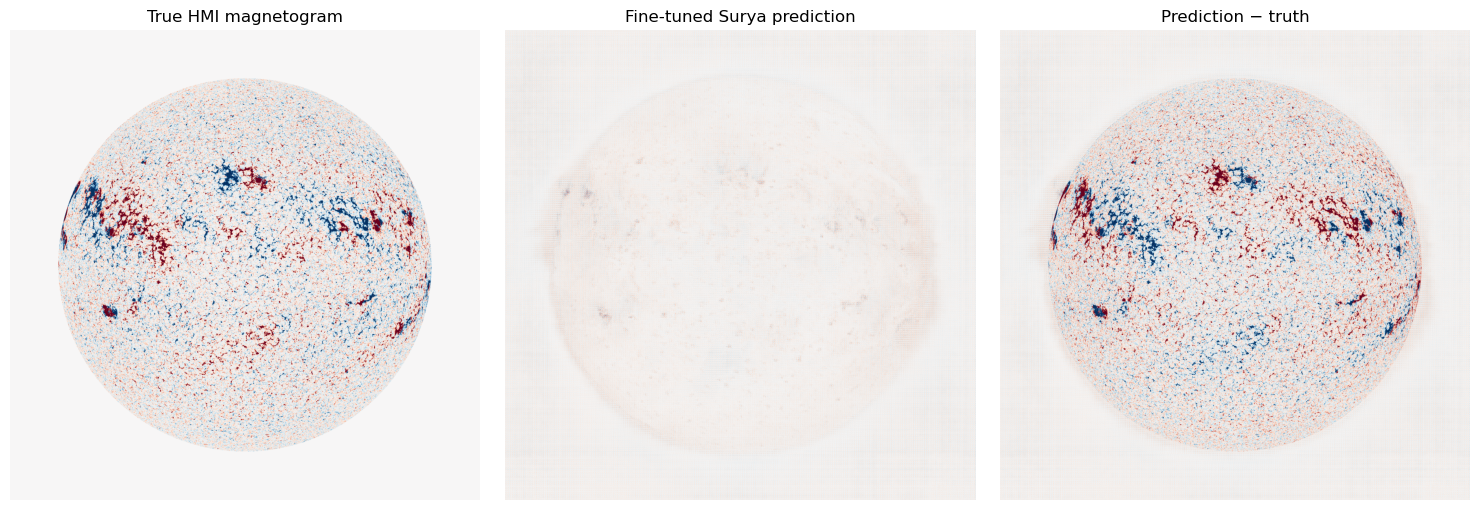

In [48]:
import matplotlib.pyplot as plt

pred = prediction_physical[0, 0].detach().cpu()[::2, ::2]
truth = target_physical[0, 0].detach().cpu()[::2, ::2]
residual = pred - truth

limit = torch.quantile(
    torch.cat([pred.abs().flatten(), truth.abs().flatten()]),
    0.99,
).item()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(truth, cmap="RdBu_r", vmin=-limit, vmax=limit)
axes[0].set_title("True HMI magnetogram")

axes[1].imshow(pred, cmap="RdBu_r", vmin=-limit, vmax=limit)
axes[1].set_title("Fine-tuned Surya prediction")

axes[2].imshow(residual, cmap="RdBu_r", vmin=-limit, vmax=limit)
axes[2].set_title("Prediction − truth")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()